<div style="
    background-color:#0b3c5d;
    color:white;
    padding:18px;
    border-radius:18px;
    text-align:center;
    box-shadow:0px 4px 12px rgba(0,0,0,0.3);
    margin-bottom:20px;
">
    <h1 style="margin:0;">🛳️ Titanic Dataset 🧊</h1>
</div>


<center>
  <img src="OIP.webp" width="800">
</center>


## Objective:
- Analyze and understand the factors that influenced passenger survival and mortality 💔.
- Explore relationships between passenger attributes and survival outcomes.
- Perform exploratory data analysis (EDA) to identify meaningful patterns and trends.

### 📋 Dataset Schema

| Column Name     | Description                                                                                                                                                   |
| --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **PassengerId** | A unique identifier assigned to each passenger. It has no analytical significance and is mainly used for record tracking.                                     |
| **Survived**    | Survival indicator where `1` represents passengers who survived and `0` represents those who did not. This is the **target variable** in prediction tasks.    |
| **Pclass**      | Passenger class (`1 = First Class`, `2 = Second Class`, `3 = Third Class`). This reflects socio-economic status and strongly influences survival probability. |
| **Name**        | Full name of the passenger, including title. Titles can sometimes be engineered into useful features (e.g., Mr, Mrs, Miss).                                   |
| **Sex**         | Gender of the passenger (`male` or `female`). This is a highly influential feature in survival analysis.                                                      |
| **Age**         | Age of the passenger in years. Contains missing values. Age is important for identifying vulnerable groups such as children and elderly passengers.           |
| **SibSp**       | Number of siblings or spouses aboard the Titanic. Useful for understanding family size and social grouping effects.                                           |
| **Parch**       | Number of parents or children aboard the Titanic. Combined with `SibSp`, it helps derive family-related features.                                             |
| **Ticket**      | Ticket number of the passenger. Mostly an identifier; limited direct analytical value.                                                                        |
| **Fare**        | Amount paid for the ticket. Often correlates with passenger class and comfort level, indirectly affecting survival chances.                                   |
| **Cabin**       | Cabin number assigned to the passenger. Contains many missing values but can indicate deck level, which may relate to survival.                               |
| **Embarked**    | Port of boarding: `C = Cherbourg`, `Q = Queenstown`, `S = Southampton`. This feature reflects travel patterns and passenger demographics.                     |


In [1]:
import pandas as pd,numpy as np,seaborn as sns
from matplotlib import pyplot as plt
from sklearn import model_selection, preprocessing, impute, linear_model, ensemble, tree
import kagglehub

In [2]:
df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
    "./Titanic-Dataset.csv"
)
df.to_csv('titanic.csv',index=False)

In [3]:
df.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
559,560,1,3,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",female,36.0,1,0,345572,17.4000,NaN,S
732,733,0,2,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0000,NaN,S
189,190,0,3,"Turcin, Mr. Stjepan",male,36.0,0,0,349247,7.8958,NaN,S
726,727,1,2,"Renouf, Mrs. Peter Henry (Lillian Jefferys)",female,30.0,3,0,31027,21.0000,NaN,S
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C
338,339,1,3,"Dahl, Mr. Karl Edwart",male,45.0,0,0,7598,8.0500,NaN,S
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


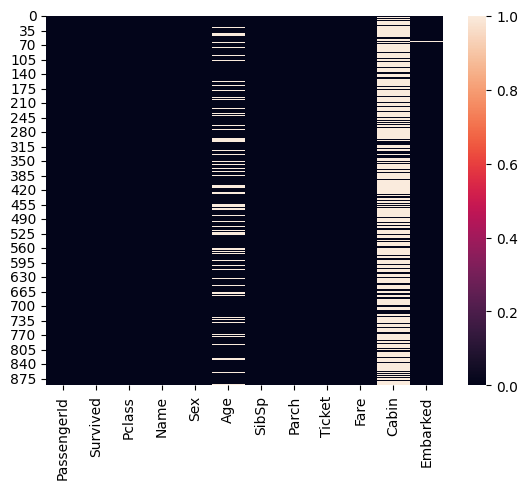

In [5]:
sns.heatmap(df.isnull())
plt.show()

In [6]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int) 
df.drop(columns='Cabin', inplace=True) 

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Has_Cabin        0
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(
    df.groupby(['Sex','Pclass'])['Age'].transform('median')
)

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

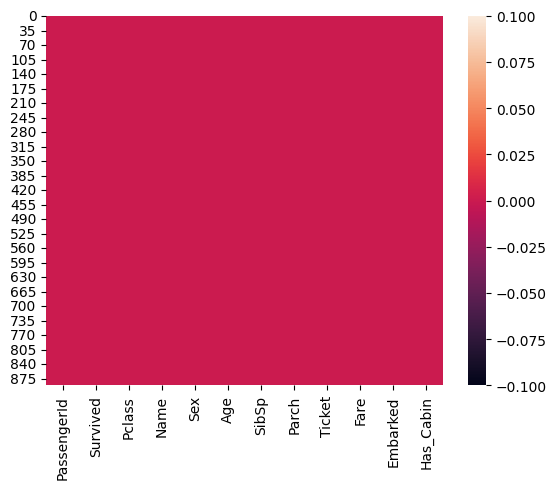

In [10]:
sns.heatmap(df.isnull())
plt.show()

In [11]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [12]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,21.5,1,2,23.4500,S,0
889,1,1,male,26.0,0,0,30.0000,C,1


In [13]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208,0.228956
std,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429,0.420397
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,0.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [14]:
df['Age'] = df['Age'].astype('int64')

In [15]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

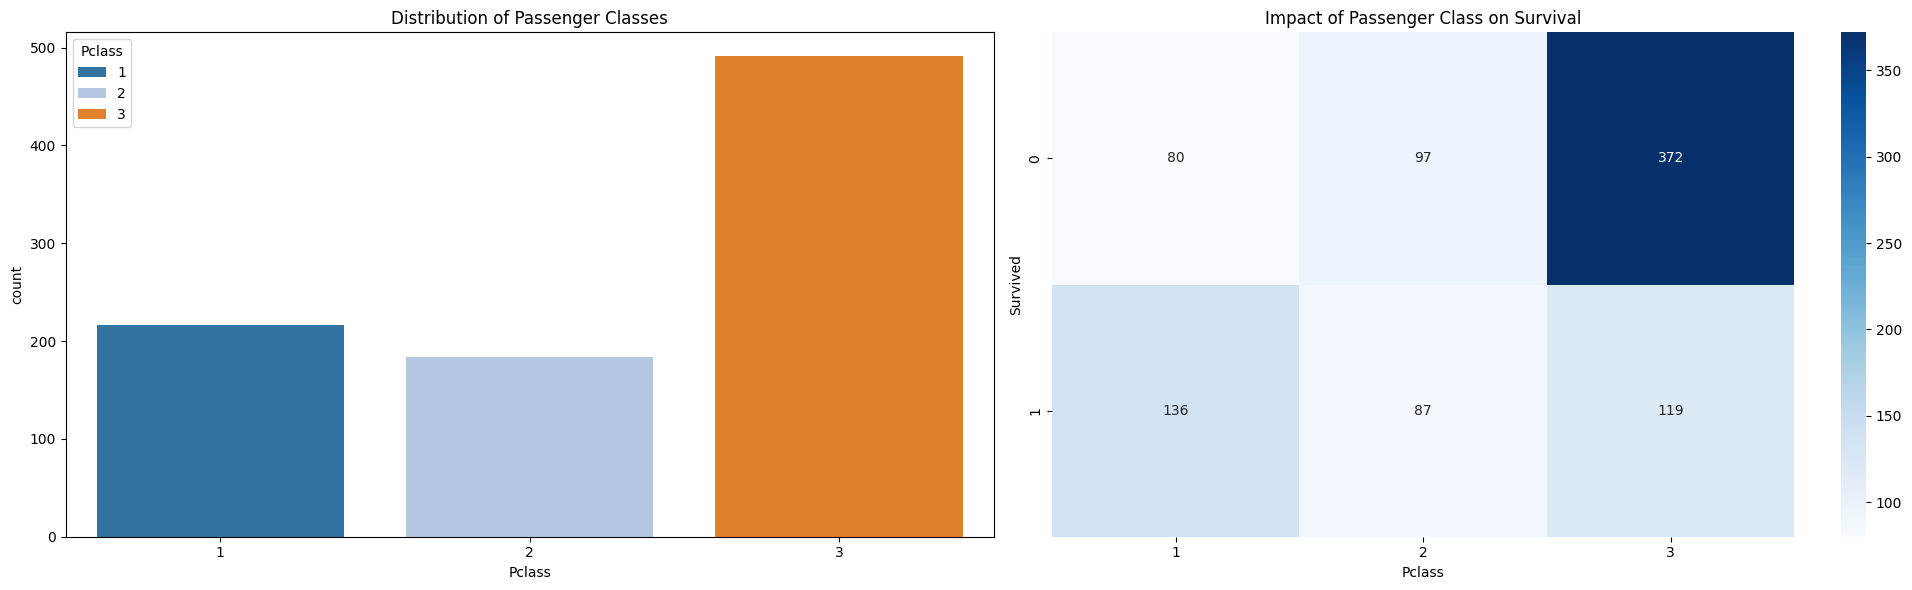

In [16]:
fig,axes = plt.subplots(1,2,figsize=(20,6))
ax=axes.flatten()
sns.countplot(df,x='Pclass',hue='Pclass',palette='tab20',ax=ax[0]).set_title('Distribution of Passenger Classes')
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass']),annot=True,fmt='d',ax=ax[1],cmap='Blues').set_title('Impact of Passenger Class on Survival')
plt.tight_layout()
plt.show()

- Passenger class had a substantial impact on survival, with higher-class passengers benefiting from significantly better survival outcomes

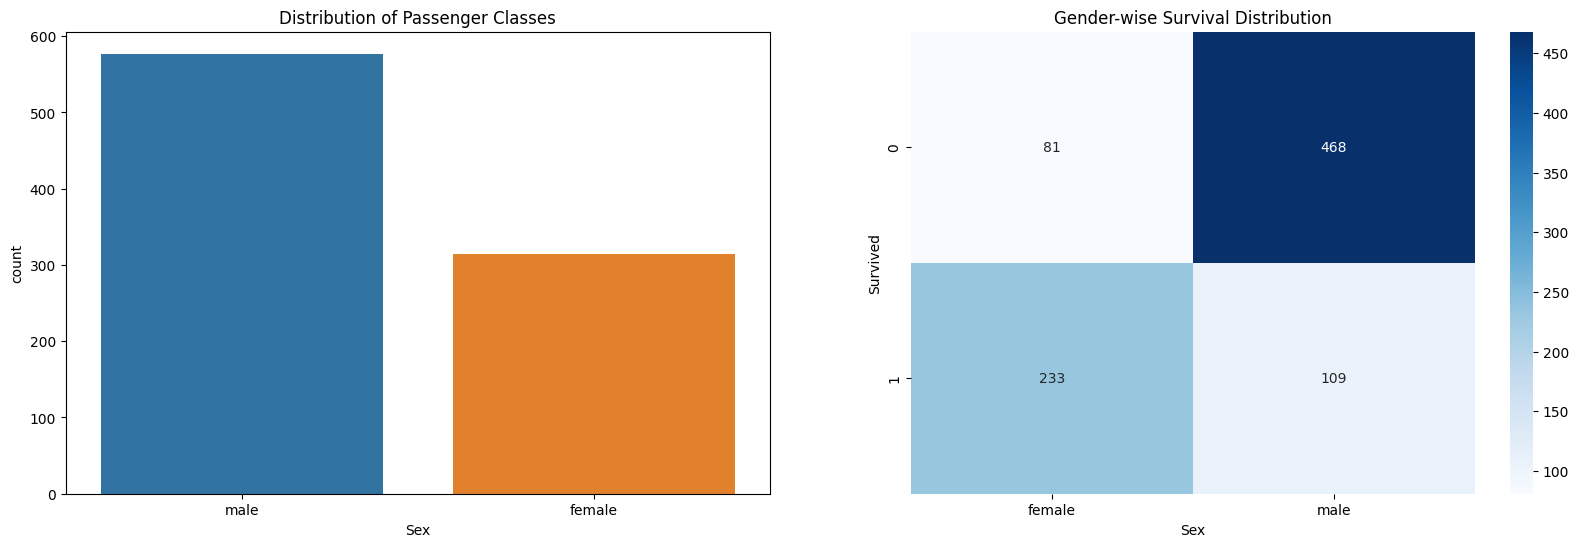

In [17]:
fig,axes = plt.subplots(1,2,figsize=(20,6))
ax=axes.flatten()
sns.countplot(df,x='Sex',hue='Sex',ax=ax[0]).set_title('Distribution of Passenger Classes')
sns.heatmap(pd.crosstab(df['Survived'],df['Sex']),annot=True,fmt='d',ax=ax[1],cmap='Blues').set_title("Gender-wise Survival Distribution")
plt.tight_layout
plt.show()

- Although male passengers constituted the majority onboard, survival outcomes were heavily skewed in favor of female passengers, highlighting gender as a dominant factor influencing survival.

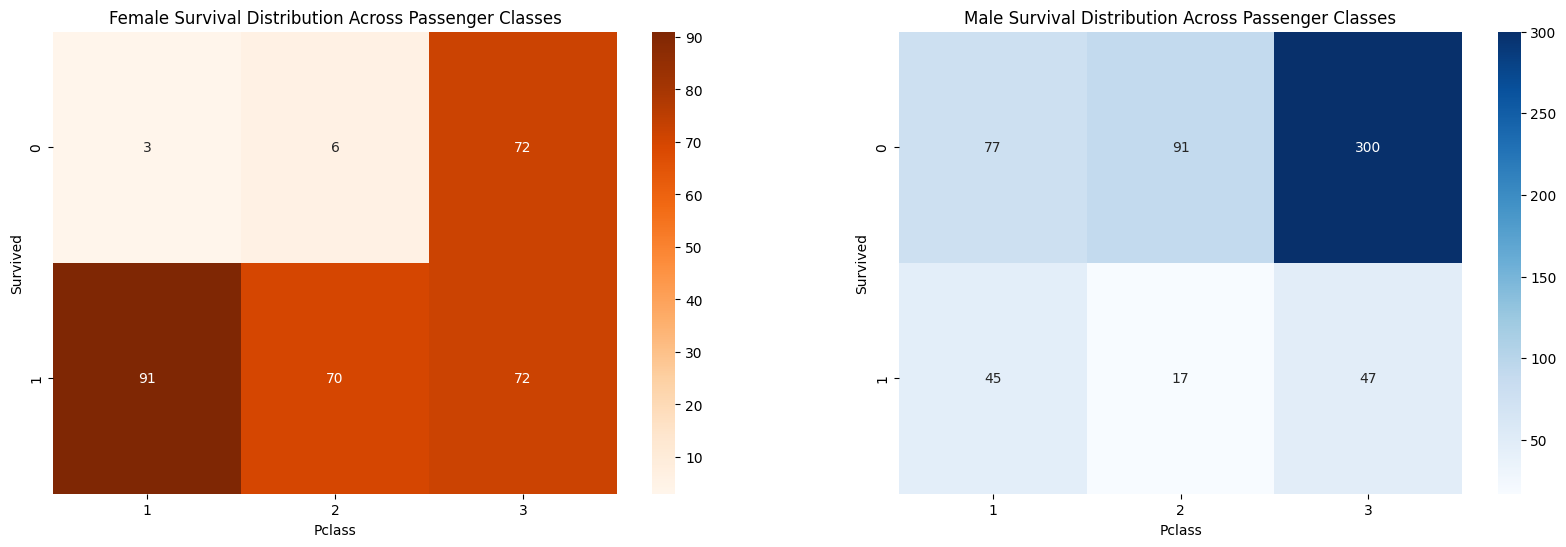

In [18]:
fig,axes = plt.subplots(1,2,figsize=(20,6))
ax=axes.flatten()

sns.heatmap(pd.crosstab(df[df['Sex']!="male"]['Survived'],df[df['Sex']!="male"]['Pclass']),annot=True,fmt='d',ax=ax[0],cmap='Oranges').set_title('Female Survival Distribution Across Passenger Classes')
sns.heatmap(pd.crosstab(df[df['Sex']=="male"]['Survived'],df[df['Sex']=="male"]['Pclass']),annot=True,fmt='d',ax=ax[1],cmap='Blues').set_title('Male Survival Distribution Across Passenger Classes')


plt.tight_layout
plt.show()

- Across all passenger classes, female passengers consistently had higher survival rates, while male passengers—particularly in lower classes—faced significantly higher mortality.

In [19]:
df.Age.max()

80

In [20]:
bins = [0,4,9,14,19,24,29,34,39,44,49,54,59,64,70,80]
groups = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-70','71-80']
df['Age_group'] = pd.cut(df['Age'],bins=bins,labels=groups)

In [21]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Age_group
0,0,3,male,22,1,0,7.2500,S,0,20-24
1,1,1,female,38,1,0,71.2833,C,1,35-39
2,1,3,female,26,0,0,7.9250,S,0,25-29
3,1,1,female,35,1,0,53.1000,S,1,35-39
4,0,3,male,35,0,0,8.0500,S,0,35-39
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S,0,25-29
887,1,1,female,19,0,0,30.0000,S,1,15-19
888,0,3,female,21,1,2,23.4500,S,0,20-24
889,1,1,male,26,0,0,30.0000,C,1,25-29


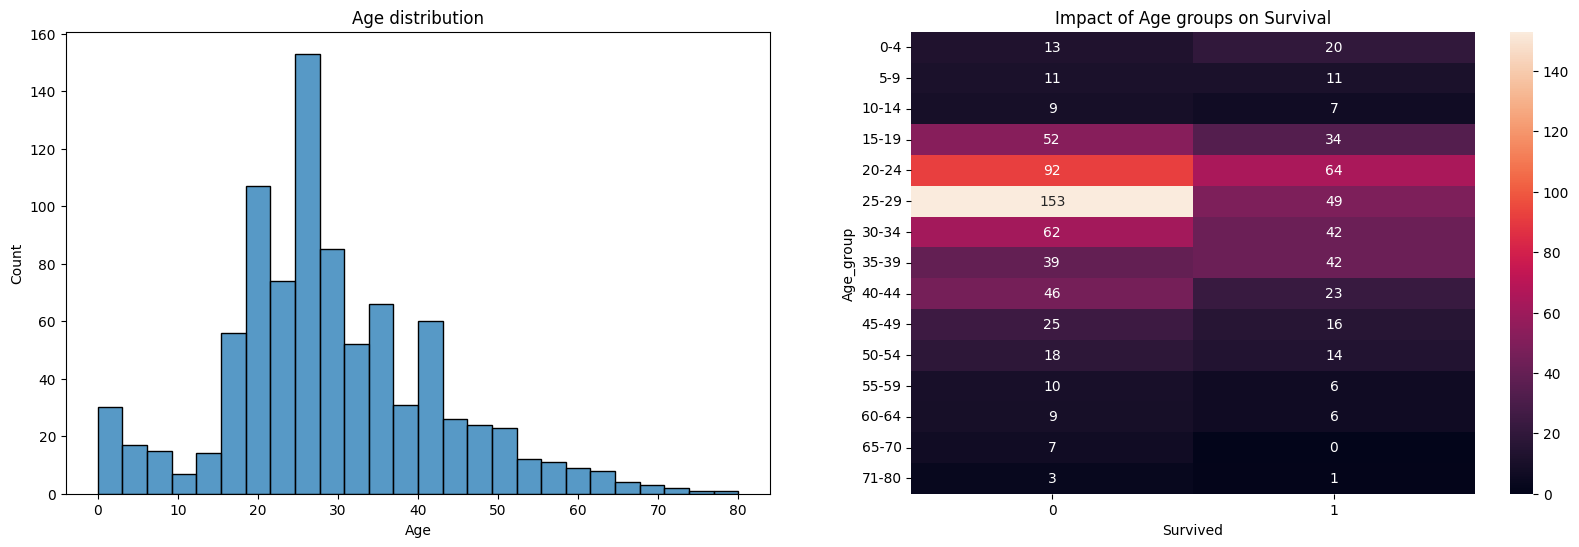

In [22]:
fig,axes = plt.subplots(1,2,figsize=(20,6))
ax = axes.flatten()
sns.histplot(df,x='Age',ax=ax[0]).set_title("Age distribution")
sns.heatmap(pd.crosstab(df['Age_group'],df['Survived']),annot=True,fmt='d',ax=ax[1]).set_title('Impact of Age groups on Survival')
plt.show()

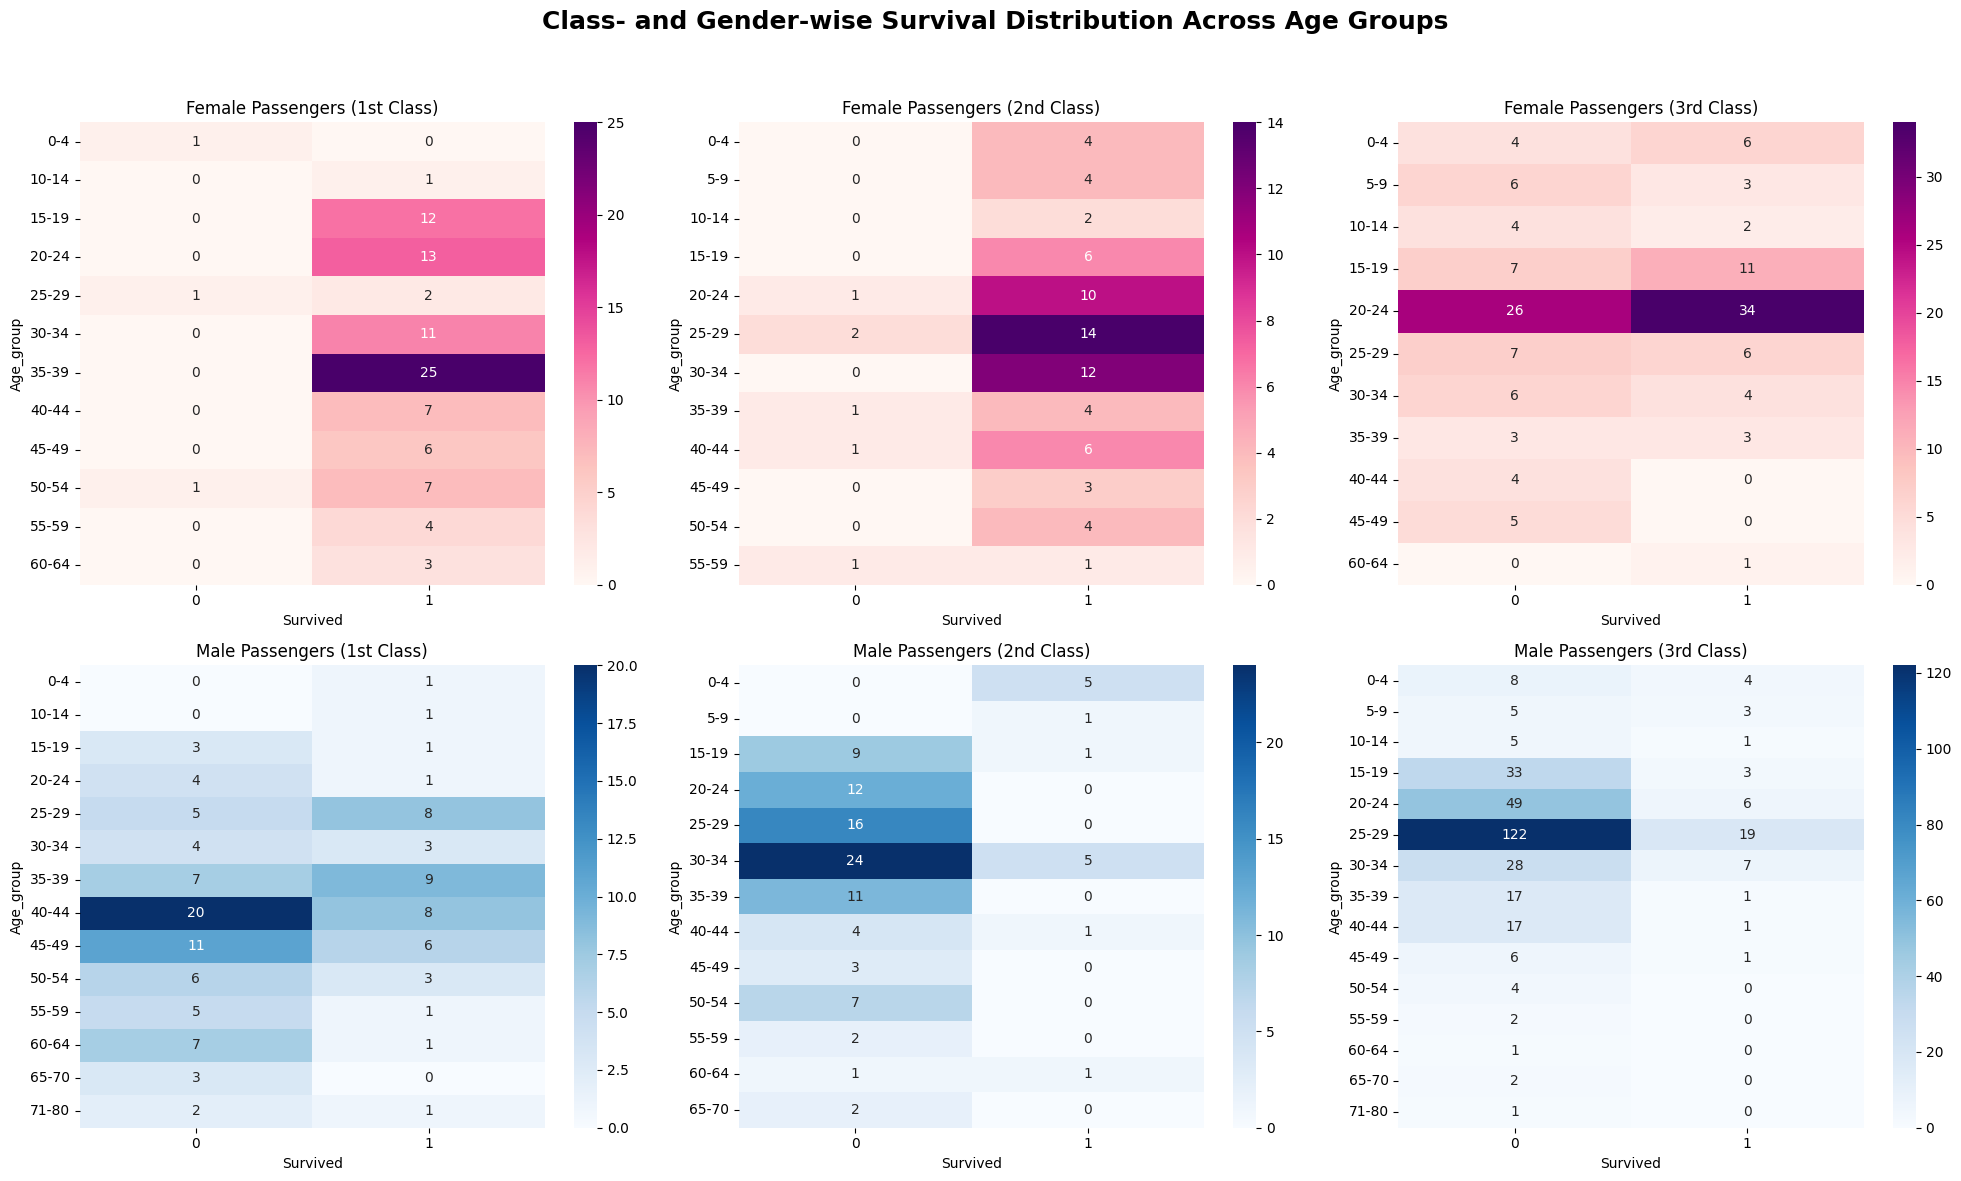

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()

plt.suptitle(
    'Class- and Gender-wise Survival Distribution Across Age Groups',
    fontsize=18, fontweight='bold'
)

# ================= FEMALES (axes 0,1,2) =================

# Pclass 1 - Female
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] != 'male') & (df['Pclass'] == 1)]['Age_group'],
        df[(df['Sex'] != 'male') & (df['Pclass'] == 1)]['Survived']
    ),
    annot=True, fmt='d', cmap='RdPu', ax=ax[0]
)
ax[0].set_title('Female Passengers (1st Class)')

# Pclass 2 - Female
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] != 'male') & (df['Pclass'] == 2)]['Age_group'],
        df[(df['Sex'] != 'male') & (df['Pclass'] == 2)]['Survived']
    ),
    annot=True, fmt='d', cmap='RdPu', ax=ax[1]
)
ax[1].set_title('Female Passengers (2nd Class)')

# Pclass 3 - Female
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] != 'male') & (df['Pclass'] == 3)]['Age_group'],
        df[(df['Sex'] != 'male') & (df['Pclass'] == 3)]['Survived']
    ),
    annot=True, fmt='d', cmap='RdPu', ax=ax[2]
)
ax[2].set_title('Female Passengers (3rd Class)')


# ================= MALES (axes 3,4,5) =================

# Pclass 1 - Male
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] == 'male') & (df['Pclass'] == 1)]['Age_group'],
        df[(df['Sex'] == 'male') & (df['Pclass'] == 1)]['Survived']
    ),
    annot=True, fmt='d', cmap='Blues', ax=ax[3]
)
ax[3].set_title('Male Passengers (1st Class)')

# Pclass 2 - Male
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] == 'male') & (df['Pclass'] == 2)]['Age_group'],
        df[(df['Sex'] == 'male') & (df['Pclass'] == 2)]['Survived']
    ),
    annot=True, fmt='d', cmap='Blues', ax=ax[4]
)
ax[4].set_title('Male Passengers (2nd Class)')

# Pclass 3 - Male
sns.heatmap(
    pd.crosstab(
        df[(df['Sex'] == 'male') & (df['Pclass'] == 3)]['Age_group'],
        df[(df['Sex'] == 'male') & (df['Pclass'] == 3)]['Survived']
    ),
    annot=True, fmt='d', cmap='Blues', ax=ax[5]
)
ax[5].set_title('Male Passengers (3rd Class)')


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 🔍 Key Insights: Survival Patterns by Age, Gender & Passenger Class
### 1 Gender as the Dominant Survival Factor

- Across all passenger classes and age groups, female passengers consistently exhibit higher survival counts than males.

- This strongly reflects the historical evacuation priority of “women and children first.”

### 2️ Passenger Class Strongly Influenced Outcomes

- 1st-class passengers show the highest survival across nearly all age groups.

- 3rd-class passengers, particularly males, experienced the highest mortality rates, highlighting class-based access limitations during evacuation.

### 3️ Female Survival Advantage Persisted Across Classes

- Even in 2nd and 3rd class, female passengers maintained relatively higher survival across most age groups.

- While survival decreases with lower class, gender advantage remains evident.

### 4️ Male Survival Declines Sharply with Lower Class

- 1st-class males show limited but visible survival in adult age groups.

- 2nd-class males display further reduced survival.

- 3rd-class males, especially those aged 20–40, show extremely low survival, forming the most vulnerable group.

### 5️ Children Had Relatively Better Survival Chances

- Younger age groups (0–14 years) generally demonstrate better survival outcomes.

- Female children show the strongest survival, while male children still fare better than adult males.

### 6️ Adult Males (20–40) Were the Most Affected Group

- This age range contains the highest concentration of fatalities, particularly in 3rd class.

- Indicates combined effects of social priority, physical location, and class constraints.

## Summary Insight

- Survival aboard the Titanic was primarily influenced by gender, followed by passenger class, with age acting as a secondary modifier rather than an independent determinant.

### Observation 

Interestingly, the age distribution peaks around young adulthood (20–35 years), which also corresponds to the group with the highest number of fatalities.  
The data subtly reminds us that survival on the Titanic was not aligned with physical strength or age advantage, but rather with social priority.


In [24]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Age_group
0,0,3,male,22,1,0,7.2500,S,0,20-24
1,1,1,female,38,1,0,71.2833,C,1,35-39
2,1,3,female,26,0,0,7.9250,S,0,25-29
3,1,1,female,35,1,0,53.1000,S,1,35-39
4,0,3,male,35,0,0,8.0500,S,0,35-39
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S,0,25-29
887,1,1,female,19,0,0,30.0000,S,1,15-19
888,0,3,female,21,1,2,23.4500,S,0,20-24
889,1,1,male,26,0,0,30.0000,C,1,25-29


In [25]:
df['familysize'] = df['SibSp'] + df['Parch'] +1

In [26]:
df['familysize'].value_counts()

familysize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

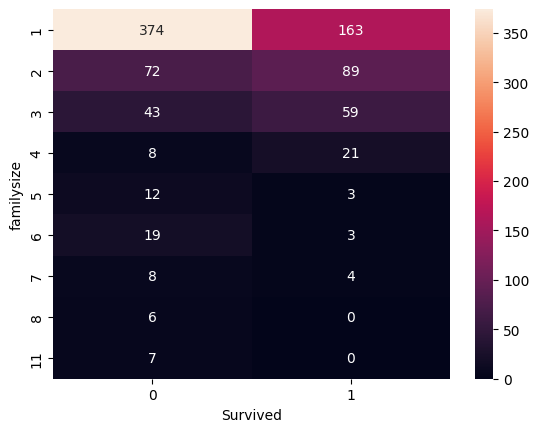

In [27]:
sns.heatmap(pd.crosstab(df['familysize'],df['Survived']),annot=True,fmt='d')
plt.show()

- Survival probability was highest for passengers traveling in small families (2–3 members), while both solo travelers and large families experienced significantly lower survival rates.

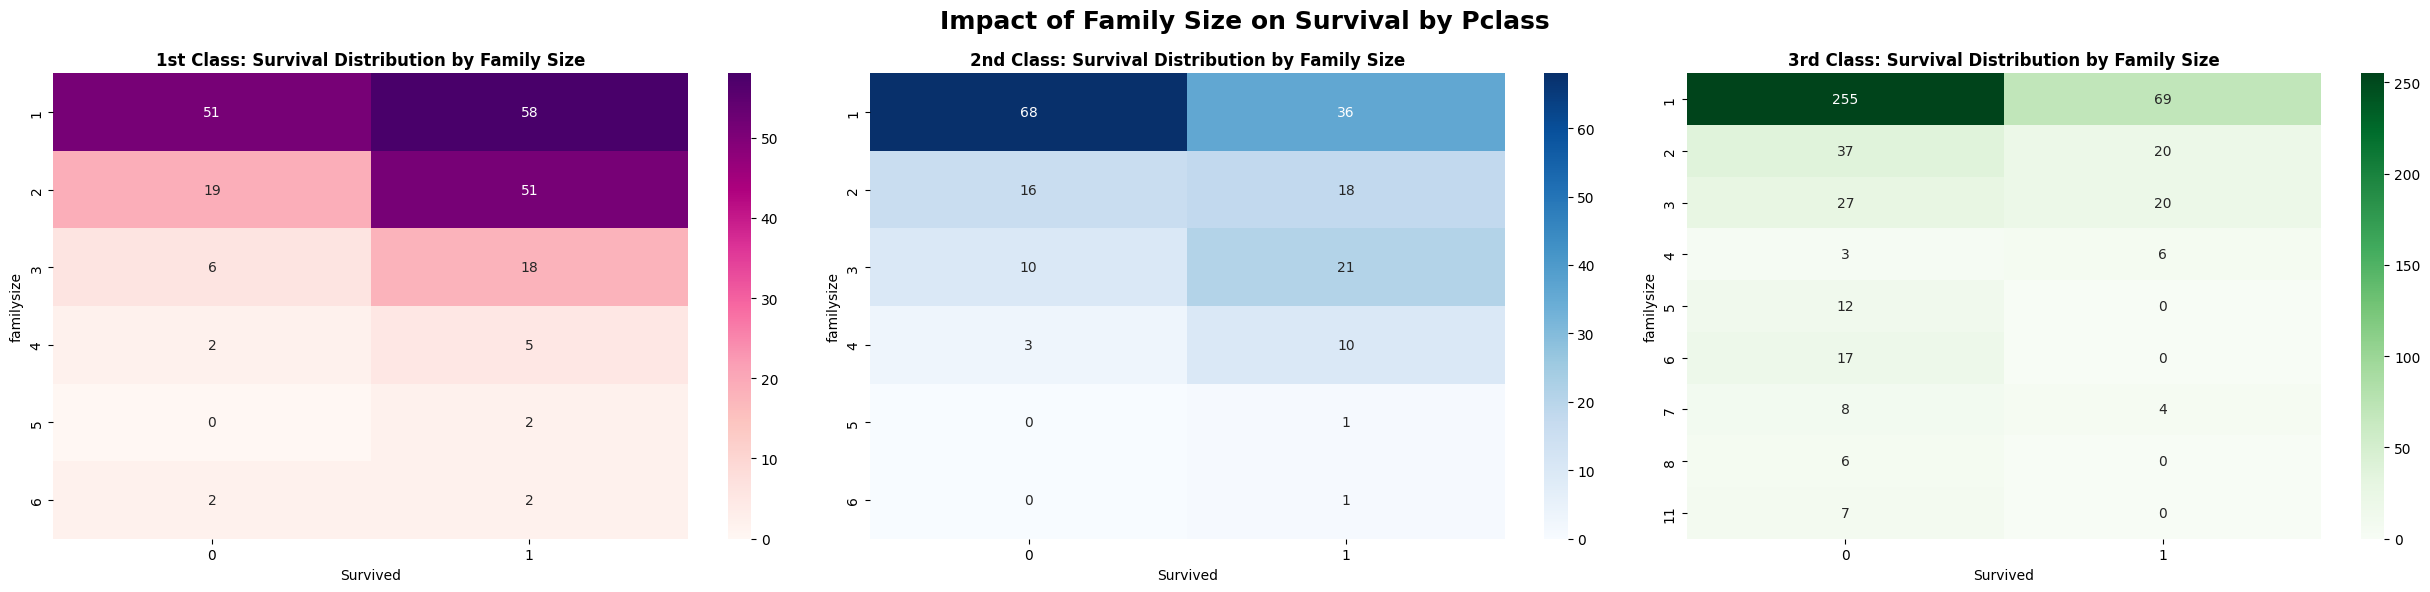

In [28]:
fig,axes = plt.subplots(1,3,figsize=(25,6))
plt.suptitle(
    'Impact of Family Size on Survival by Pclass',
    fontsize=18,
    fontweight='bold'
)
sns.heatmap(pd.crosstab(df[df['Pclass']==1]['familysize'],df[df['Pclass']==1]['Survived']),ax=axes[0],annot=True,fmt='d',cmap='RdPu')
sns.heatmap(pd.crosstab(df[df['Pclass']==2]['familysize'],df[df['Pclass']==2]['Survived']),ax=axes[1],annot=True,fmt='d',cmap='Blues')
sns.heatmap(pd.crosstab(df[df['Pclass']==3]['familysize'],df[df['Pclass']==3]['Survived']),ax=axes[2],annot=True,fmt='d',cmap='Greens')

axes[0].set_title(
    '1st Class: Survival Distribution by Family Size',
    fontsize=12, fontweight='bold'
)

axes[1].set_title(
    '2nd Class: Survival Distribution by Family Size',
    fontsize=12, fontweight='bold'
)

axes[2].set_title(
    '3rd Class: Survival Distribution by Family Size',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

- While small family size generally improved survival, passenger class played a decisive role—higher-class passengers consistently exhibited better survival outcomes across all family sizes.

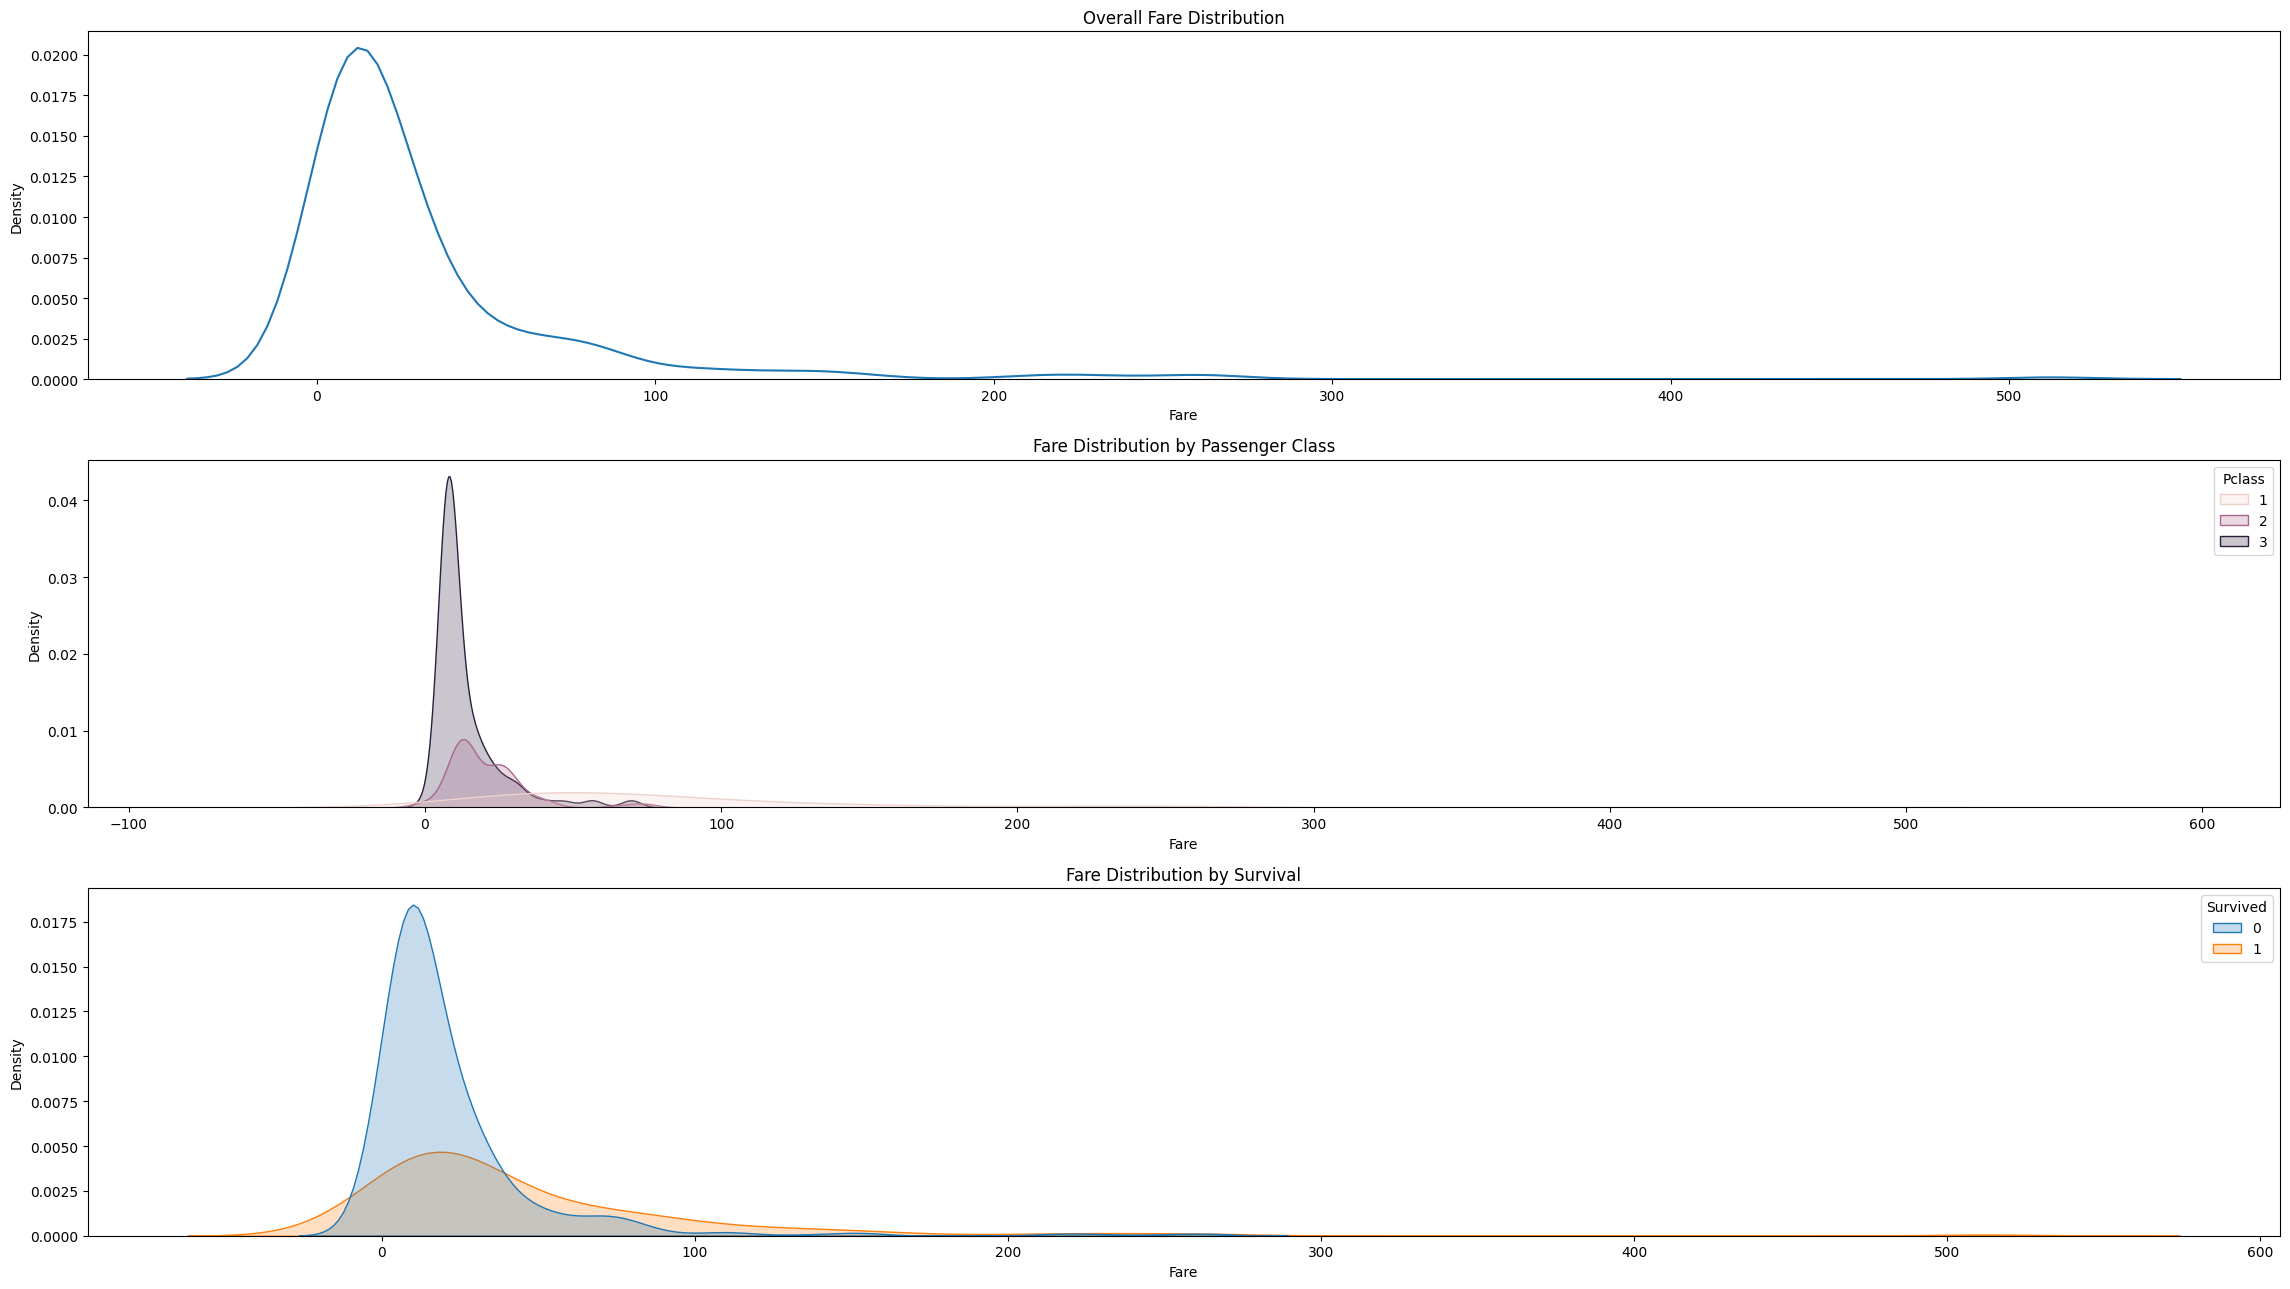

In [29]:
fig,axes=plt.subplots(3,1,figsize=(23,13))
ax = axes.flatten()

sns.kdeplot(df,x='Fare',ax=ax[0]).set_title('Overall Fare Distribution')
sns.kdeplot(df,x='Fare',fill=True,hue='Pclass',ax=ax[1]).set_title('Fare Distribution by Passenger Class')
sns.kdeplot(df,x='Fare',fill=True,hue='Survived',ax=ax[2]).set_title('Fare Distribution by Survival')
plt.tight_layout()
plt.show()

## Key Insights:
### 1️ Overall Fare Distribution

- The fare distribution is heavily right-skewed, with most passengers paying low fares.

- A long right tail indicates the presence of a small number of passengers who paid very high fares, likely corresponding to luxury accommodations.

- This skewness suggests that fare is not normally distributed and may benefit from transformation (e.g., log scale) for modeling.

### 2️ Fare Distribution by Passenger Class

- Clear separation exists between passenger classes:

- 3rd class passengers are concentrated at very low fare values.

- 2nd class fares lie in an intermediate range.

- 1st class passengers paid substantially higher fares, with a wide spread and long tail.

- The overlap between classes is minimal, confirming that fare strongly reflects socio-economic status.

## 3️ Fare Distribution by Survival

- Survivors generally exhibit a shift toward higher fare values compared to non-survivors.

- Non-survivors are densely concentrated in the lowest fare range.

- This suggests that paying a higher fare increased the likelihood of survival, likely due to better cabin location and access to lifeboats.

## Summary Insight

- Fare is a strong proxy for socio-economic status and shows a clear association with survival, with higher-paying passengers exhibiting improved survival outcomes.
- Due to heavy right skew, Fare may benefit from log transformation prior to model training.

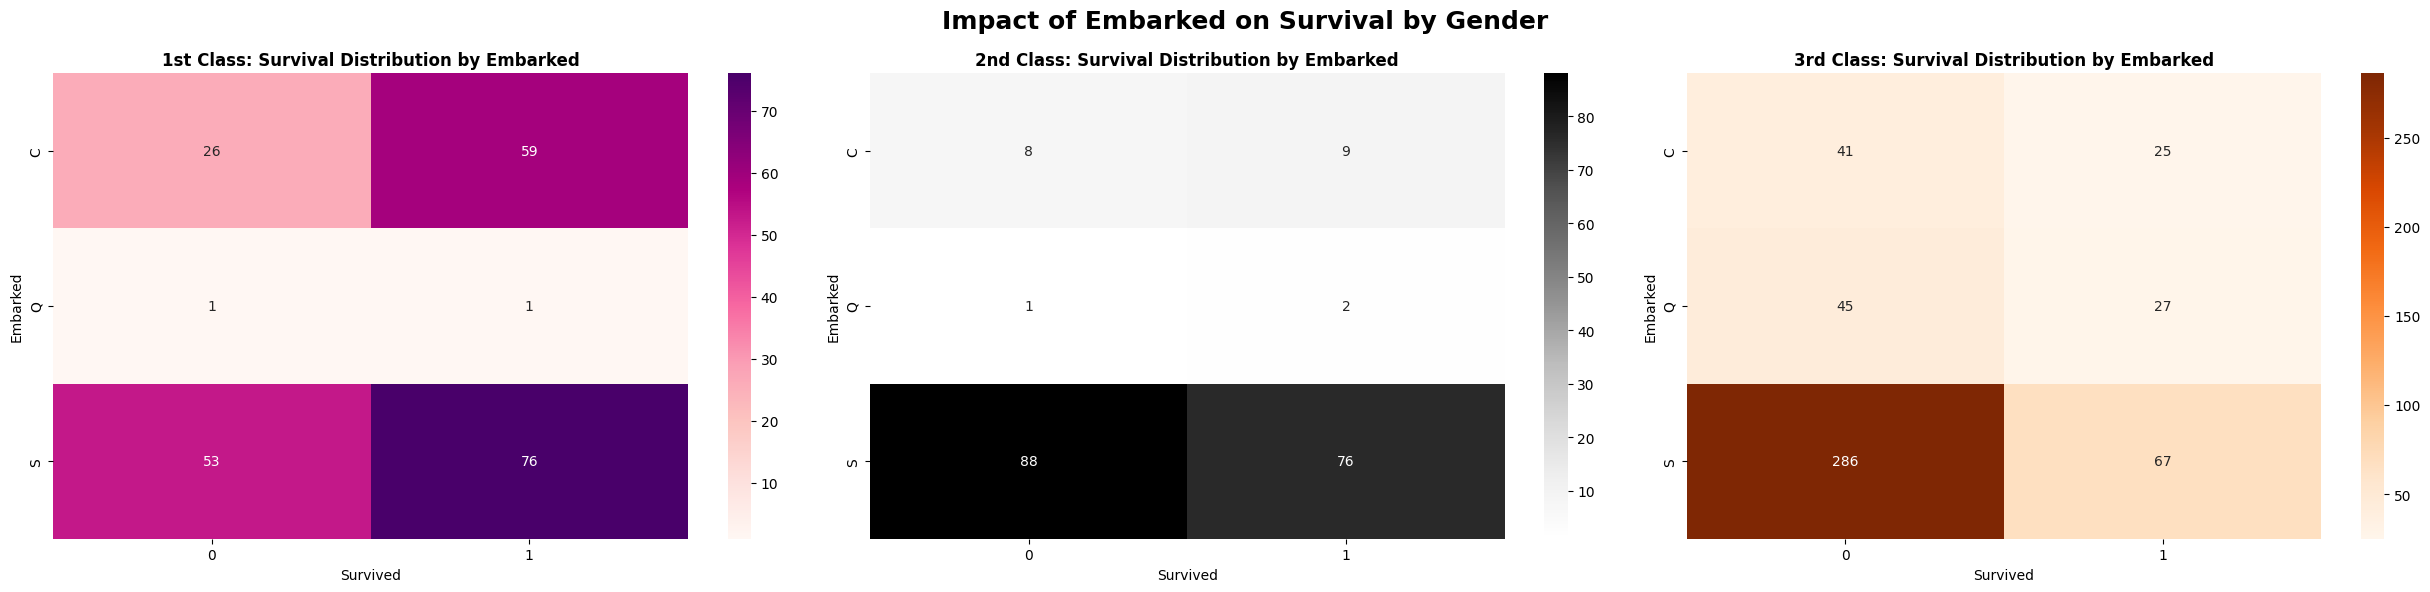

In [30]:
fig,axes = plt.subplots(1,3,figsize=(25,6))
plt.suptitle(
    'Impact of Embarked on Survival by Gender',
    fontsize=18,
    fontweight='bold'
)
sns.heatmap(pd.crosstab(df[df['Pclass']==1]['Embarked'],df[df['Pclass']==1]['Survived']),ax=axes[0],annot=True,fmt='d',cmap='RdPu')
sns.heatmap(pd.crosstab(df[df['Pclass']==2]['Embarked'],df[df['Pclass']==2]['Survived']),ax=axes[1],annot=True,fmt='d',cmap='Greys')
sns.heatmap(pd.crosstab(df[df['Pclass']==3]['Embarked'],df[df['Pclass']==3]['Survived']),ax=axes[2],annot=True,fmt='d',cmap='Oranges')

axes[0].set_title(
    '1st Class: Survival Distribution by Embarked',
    fontsize=12, fontweight='bold'
)

axes[1].set_title(
    '2nd Class: Survival Distribution by Embarked',
    fontsize=12, fontweight='bold'
)

axes[2].set_title(
    '3rd Class: Survival Distribution by Embarked',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

- C = Cherbourg
- Q = Queenstown
- S = Southampton

In [31]:
df.to_csv('data/processed/titanic_p.csv',index=False)

# Final Insights & Conclusions

- Gender emerged as the strongest survival determinant, with female passengers showing consistently higher survival rates across all passenger classes and age groups. This reflects the “women and children first” evacuation policy.

- Passenger class played a critical socio-economic role in survival outcomes. First-class passengers had significantly higher survival probabilities compared to second and third class, indicating unequal access to safety resources.

- Age showed a non-linear relationship with survival. Children and younger passengers had better survival outcomes, while survival probability declined notably among older age groups.

- Family structure influenced survival chances. Passengers traveling with small families exhibited higher survival rates than those traveling alone or in very large families, suggesting optimal group support during evacuation.

- Cabin availability acted as a proxy for passenger status. Passengers with recorded cabin information were more likely to survive, reinforcing its association with higher passenger class and favorable deck location.

- Embarkation port had a secondary but observable effect, correlating with class distribution and fare differences rather than acting as a primary survival driver.

- Missing value handling was deliberately conservative:

    - Age was imputed using statistically informed strategies due to its strong predictive relevance.

    - Cabin was reduced to a binary availability feature to avoid fabricating structural information.

    - Embarked values were imputed using the most frequent category given their negligible count.

- Feature engineering focused on interpretability over complexity, ensuring all derived features (age groups, family size, cabin availability) could be clearly explained and justified in a real-world context.